## cdna2和ptmul-nr

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

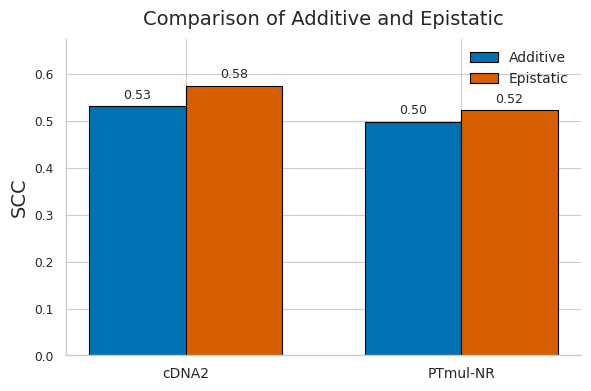

[OK] Figure saved to: ./dataset/epistasis_vs_additive_2x2.png


In [2]:
# ===============================
# 数据集配置
# ===============================
DATASETS = {
    "cDNA2": "./dataset/cdna2/predictions/cdna2_processed_with_prediction_add.csv",
    "PTmul-NR": "./dataset/ptmul_nr/predictions/ptmul_nr_processed_with_prediction_add.csv",
}

OUTPUT_FIGURE = "./dataset/epistasis_vs_additive_2x2.png"

COL_EXP = "ddg"
COL_ADD = "add"
COL_EPI = "PreDDG"

# ===============================
# 绘图风格
# ===============================
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

sns.set(style="whitegrid", context="paper")

# Okabe–Ito 色盲友好配色
COLOR_ADD = "#0072B2"   # 蓝
COLOR_EPI = "#D55E00"   # 橙

# ===============================
# 计算 Spearman
# ===============================
results = []

for dataset_name, csv_path in DATASETS.items():
    df = pd.read_csv(csv_path)
    df = df[[COL_EXP, COL_ADD, COL_EPI]].dropna()

    rho_add, _ = spearmanr(df[COL_EXP], df[COL_ADD])
    rho_epi, _ = spearmanr(df[COL_EXP], df[COL_EPI])

    results.append({
        "Dataset": dataset_name,
        "Method": "Additive",
        "Spearman": rho_add
    })
    results.append({
        "Dataset": dataset_name,
        "Method": "Epistatic",
        "Spearman": rho_epi
    })

plot_df = pd.DataFrame(results)

# ===============================
# 绘制 2×2 分组柱状图
# ===============================
fig, ax = plt.subplots(figsize=(6, 4))

bar_width = 0.35
x = np.arange(len(plot_df["Dataset"].unique()))

# 拆分数据
add_scores = plot_df[plot_df["Method"] == "Additive"]["Spearman"].values
epi_scores = plot_df[plot_df["Method"] == "Epistatic"]["Spearman"].values

bars_add = ax.bar(
    x - bar_width / 2,
    add_scores,
    bar_width,
    label="Additive",
    color=COLOR_ADD,
    edgecolor="black",
    linewidth=0.8
)

bars_epi = ax.bar(
    x + bar_width / 2,
    epi_scores,
    bar_width,
    label="Epistatic",
    color=COLOR_EPI,
    edgecolor="black",
    linewidth=0.8
)

# 数值标注
for bars in [bars_add, bars_epi]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# ===============================
# 坐标轴 & 图例
# ===============================
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Dataset"].unique(), fontsize=10)
ax.set_ylabel("SCC", fontsize=14)

ax.set_ylim(0, max(plot_df["Spearman"]) + 0.1)

ax.legend(frameon=False, fontsize=10)

ax.set_title(
    "Comparison of Additive and Epistatic",
    fontsize=14,
    pad=10
)

# 去掉多余边框
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE, dpi=300)
plt.show()
plt.close()

print(f"[OK] Figure saved to: {OUTPUT_FIGURE}")

In [3]:
# ====================== 1. 基础配置 ======================
data_name = 'ptmul_nr'
INPUT_CSV = f"./dataset/{data_name}/predictions/{data_name}_processed_with_prediction_add.csv"
OUTPUT_METRICS = f"./dataset/{data_name}/add_evaluation_metrics.csv"
OUTPUT_FIGURE = f"./dataset/{data_name}/epistasis_vs_additive.png"

# 列名（严格对应你的数据）
COL_EXP = "ddg"        # 实验ddg
COL_ADD = "add"        # 加性预测ddg
COL_EPI = "PreDDG"     # 上位效应预测ddg
# COL_EPI = "preddg"     # 上位效应预测ddg

# 绘图中文/负号设置
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

In [4]:
# ====================== 2. 读取与清洗数据 ======================
df = pd.read_csv(INPUT_CSV)

# 检查必须列
required_cols = [COL_EXP, COL_ADD, COL_EPI]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"数据中缺少必需列: {c}")

# 去空值
df_valid = df[required_cols].dropna().reset_index(drop=True)
y_true = df_valid[COL_EXP]
y_add = df_valid[COL_ADD]
y_epi = df_valid[COL_EPI]

print(f"有效样本数: {len(df_valid)}")
if len(df_valid) < 10:
    print("警告：有效样本过少，评估结果可能不可靠")

有效样本数: 82


In [5]:
# ====================== 3. 计算评估指标函数 ======================
def calc_metrics(y_obs, y_pred):
    rmse = np.sqrt(np.mean((y_obs - y_pred) ** 2))
    mae = np.mean(np.abs(y_obs - y_pred))
    r, _ = stats.pearsonr(y_obs, y_pred)
    r2 = r ** 2
    spear, spearman_p = stats.spearmanr(y_obs, y_pred)
    return {
        "RMSE": rmse,
        "MAE": mae,
        "Pearson_r": r,
        "Spearman_r": spear,
        "Spearman_p": spearman_p,
        "R2": r2
    }

metrics_add = calc_metrics(y_true, y_add)
metrics_epi = calc_metrics(y_true, y_epi)

# 整理成表格
metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "Pearson_r", "Spearman_r", "Spearman_p", "R2"],
    "Additive": [metrics_add[m] for m in ["RMSE", "MAE", "Pearson_r", "Spearman_r", "Spearman_p", "R2"]],
    "Epistasis": [metrics_epi[m] for m in ["RMSE", "MAE", "Pearson_r", "Spearman_r", "Spearman_p", "R2"]]
})

# 保存指标
metrics_df.to_csv(OUTPUT_METRICS, index=False, float_format="%.4f")
# ====================== 4. 打印指标结果 ======================
print("\n" + "="*60)
print("          加性方法 vs 上位效应方法 预测性能评估")
print("="*60)
print(metrics_df.round(4))
print("="*60)

# 自动文字结论
print("\n【结论：是否更优？】")

if metrics_epi["Pearson_r"] > metrics_add["Pearson_r"]:
    print(f"✅ 上位效应方法 Pearson_r({metrics_epi['Pearson_r']:.4f}) > 加性({metrics_add['Pearson_r']:.4f})")
else:
    print(f"❌ 上位效应方法 Pearson_r 未优于加性")

if metrics_epi["Spearman_r"] > metrics_add["Spearman_r"]:
    print(f"✅ 上位效应方法 Spearman_r({metrics_epi['Spearman_r']:.4f}) > 加性({metrics_add['Spearman_r']:.4f})")
else:
    print(f"❌ 上位效应方法 Spearman_r 未优于加性")


          加性方法 vs 上位效应方法 预测性能评估
       Metric  Additive  Epistasis
0        RMSE    2.4671     2.4554
1         MAE    1.8849     1.8604
2   Pearson_r    0.4232     0.4419
3  Spearman_r    0.4989     0.5229
4  Spearman_p    0.0000     0.0000
5          R2    0.1791     0.1953

【结论：是否更优？】
✅ 上位效应方法 Pearson_r(0.4419) > 加性(0.4232)
✅ 上位效应方法 Spearman_r(0.5229) > 加性(0.4989)


## 3i35

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, spearmanr  # 核密度+相关系数
import seaborn as sns

In [7]:
df = pd.read_csv('./dataset/3i35/mutations/epi_merged.csv')

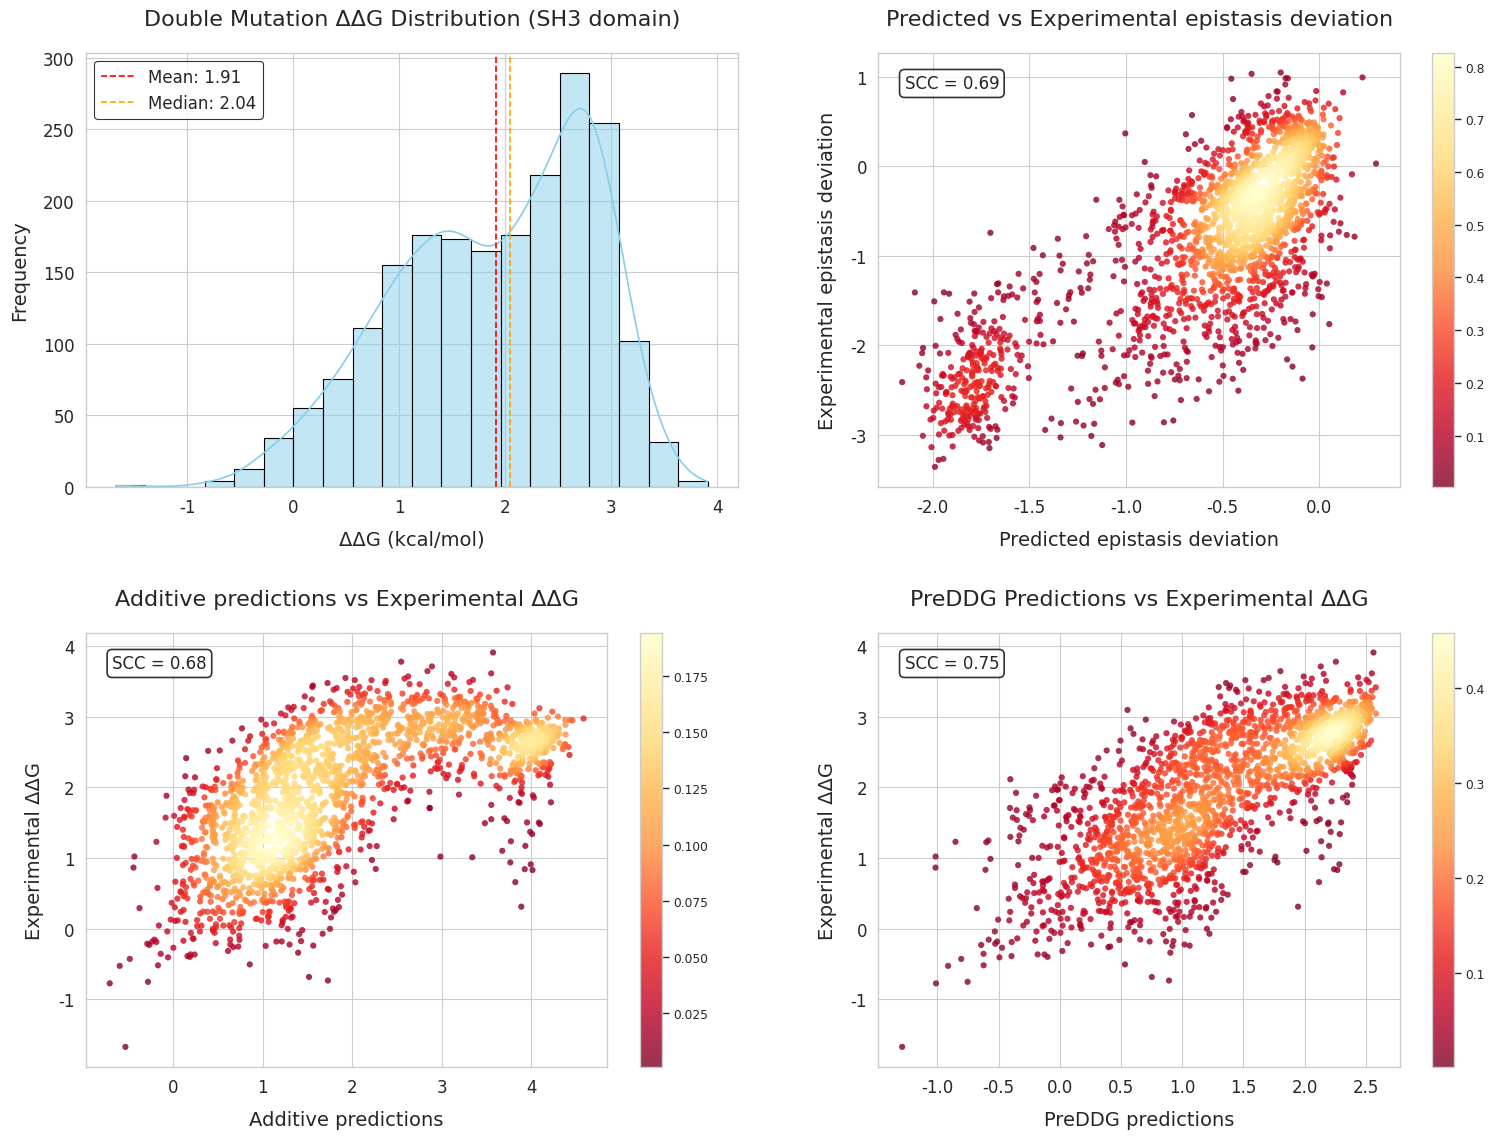

In [8]:
# ddg基础统计
ddg_stats = df["ddg_x"].describe()

# ===============================
#            绘制
# ===============================
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))  # 双层括号匹配2维结构
# 定义统一的样式参数
BOX_STYLE = {
    'boxstyle': 'round',
    'facecolor': 'white',
    'edgecolor': 'black',
    'alpha': 0.8,
    'linewidth': 1.2
}
TEXT_FONT_SIZE = 12
LEGEND_FONT_SIZE = 12

# ------------------------------
# 3.1 子图1:ΔΔG分布直方图
# ------------------------------
# 绘制直方图
sns.histplot(df["ddg_x"], bins=20, kde=True, color="skyblue", edgecolor="black", ax=ax1)

# 绘制均值和中位数竖线
ax1.axvline(ddg_stats["mean"], color="red", linestyle="--", label=f"Mean: {ddg_stats['mean']:.2f}")
ax1.axvline(ddg_stats["50%"], color="orange", linestyle="--", label=f"Median: {ddg_stats['50%']:.2f}")

# 标题与轴标签
ax1.set_title("Double Mutation ΔΔG Distribution (SH3 domain)", fontsize=16, pad=20)
ax1.set_xlabel("ΔΔG (kcal/mol)", fontsize=14, labelpad=10)
ax1.set_ylabel("Frequency", fontsize=14, labelpad=10)

# 添加图例
legend = ax1.legend(
    fontsize=LEGEND_FONT_SIZE,
    frameon=True,
    facecolor=BOX_STYLE['facecolor'],
    edgecolor=BOX_STYLE['edgecolor'],
    loc='upper left'  # 统一位置风格
)
# 设置图例边框宽度（matplotlib兼容写法）
for frame in legend.get_frame().get_children():
    if isinstance(frame, plt.Line2D):
        frame.set_linewidth(BOX_STYLE['linewidth'])

# 优化刻度
ax1.tick_params(axis="both", labelsize=12)

# ------------------------------
# 3.2 子图2:预测 epistasis deviation vs 实验 epistasis deviation
# ------------------------------


x = df['epi_ddg_pre']
y = df['epi_ddg']
# ==================== 2. 计算核密度（用于颜色映射） ====================
# 堆叠数据并计算KDE
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # 每个点的密度值
idx = z.argsort()  # 按密度排序（确保高密度点在顶层）
x_sorted, y_sorted, z_sorted = x[idx], y[idx], z[idx]

# ==================== 3. 计算统计量（spear和p值） ====================
spear, _ = spearmanr(x, y)

# 绘制密度散点图：按密度上色
# 配色：从黄到紫的渐变（匹配示例）
cmap = plt.cm.YlOrRd_r  # 反向YlOrRd（黄→红→紫）
scatter = ax2.scatter(
    x_sorted, y_sorted,
    c=z_sorted,
    s=20,  # 点的大小
    cmap=cmap,
    alpha=0.8,
    edgecolors="none",
    rasterized=True  # 提升保存图片质量
)
# 添加颜色条（右侧）
cbar = plt.colorbar(scatter, ax=ax2)

# 添加统计信息文本框
text_str = f"SCC = {spear:.2f}"
ax2.text(
    0.05, 0.95, text_str,
    transform=ax2.transAxes,
    fontsize=TEXT_FONT_SIZE,
    verticalalignment="top",
    bbox=BOX_STYLE,  # 直接使用统一的样式字典
)

# 设置标签
ax2.set_xlabel("Predicted epistasis deviation", fontsize=14, labelpad=10)
ax2.set_ylabel("Experimental epistasis deviation", fontsize=14, labelpad=10)
ax2.set_title("Predicted vs Experimental epistasis deviation", fontsize=16, pad=20)

# 优化刻度
ax2.tick_params(axis="both", labelsize=12)


# ------------------------------
# 3.3 子图3:加性预测ddg vs 实验 ddg
# ------------------------------


x = df['ddg_add_pre']
y = df['ddg_x']
# ==================== 2. 计算核密度（用于颜色映射） ====================
# 堆叠数据并计算KDE
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # 每个点的密度值
idx = z.argsort()  # 按密度排序（确保高密度点在顶层）
x_sorted, y_sorted, z_sorted = x[idx], y[idx], z[idx]

# ==================== 3. 计算统计量（pcc和p值） ====================
spear, _ = spearmanr(x, y)

# 绘制密度散点图：按密度上色
# 配色：从黄到紫的渐变（匹配示例）
cmap = plt.cm.YlOrRd_r  # 反向YlOrRd（黄→红→紫）
scatter = ax3.scatter(
    x_sorted, y_sorted,
    c=z_sorted,
    s=20,  # 点的大小
    cmap=cmap,
    alpha=0.8,
    edgecolors="none",
    rasterized=True  # 提升保存图片质量
)
# 添加颜色条（右侧）
cbar = plt.colorbar(scatter, ax=ax3)

# 添加统计信息文本框
text_str = f"SCC = {spear:.2f}"
ax3.text(
    0.05, 0.95, text_str,
    transform=ax3.transAxes,
    fontsize=TEXT_FONT_SIZE,
    verticalalignment="top",
    bbox=BOX_STYLE,  # 直接使用统一的样式字典
    # family='Arial'   # 确保字体统一
)

# 设置标签
ax3.set_xlabel("Additive predictions", fontsize=14, labelpad=10)
ax3.set_ylabel("Experimental ΔΔG", fontsize=14, labelpad=10)
ax3.set_title("Additive predictions vs Experimental ΔΔG", fontsize=16, pad=20)

# 优化刻度
ax3.tick_params(axis="both", labelsize=12)


# ------------------------------
# 子图4: PreDDG vs 实验值ddg
# ------------------------------
x = df['PreDDG']
y = df['ddg_x']
# ==================== 2. 计算核密度（用于颜色映射） ====================
# 堆叠数据并计算KDE
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)  # 每个点的密度值
idx = z.argsort()  # 按密度排序（确保高密度点在顶层）
x_sorted, y_sorted, z_sorted = x[idx], y[idx], z[idx]

# ==================== 3. 计算统计量（pcc和p值） ====================
spear, _ = spearmanr(x, y)

# 绘制密度散点图：按密度上色
# 配色：从黄到紫的渐变（匹配示例）
cmap = plt.cm.YlOrRd_r  # 反向YlOrRd（黄→红→紫）
scatter = ax4.scatter(
    x_sorted, y_sorted,
    c=z_sorted,
    s=20,  # 点的大小
    cmap=cmap,
    alpha=0.8,
    edgecolors="none",
    rasterized=True  # 提升保存图片质量
)
# 添加颜色条（右侧）
cbar = plt.colorbar(scatter, ax=ax4)

# 添加统计信息文本框
text_str = f"SCC = {spear:.2f}"
ax4.text(
    0.05, 0.95, text_str,
    transform=ax4.transAxes,
    fontsize=TEXT_FONT_SIZE,
    verticalalignment="top",
    bbox=BOX_STYLE,  # 直接使用统一的样式字典
)


# 设置标签
ax4.set_xlabel("PreDDG predictions", fontsize=14, labelpad=10)
ax4.set_ylabel("Experimental ΔΔG", fontsize=14, labelpad=10)
ax4.set_title("PreDDG Predictions vs Experimental ΔΔG", fontsize=16, pad=20)

# 优化刻度
ax4.tick_params(axis="both", labelsize=12)

# ===============================
# 4. 全局优化 & 保存
# ===============================
plt.tight_layout(pad=3.0, w_pad=6.0)

# 保存高分辨率图片
plt.savefig(
    "./dataset/3i35/3i35_ddg_ditribution_pre_ddg_scatter.png",
    dpi=300,
    bbox_inches='tight',    # 裁剪多余空白
    facecolor='white',      # 背景色（避免透明）
    edgecolor='none',       # 无边框
)
plt.show()

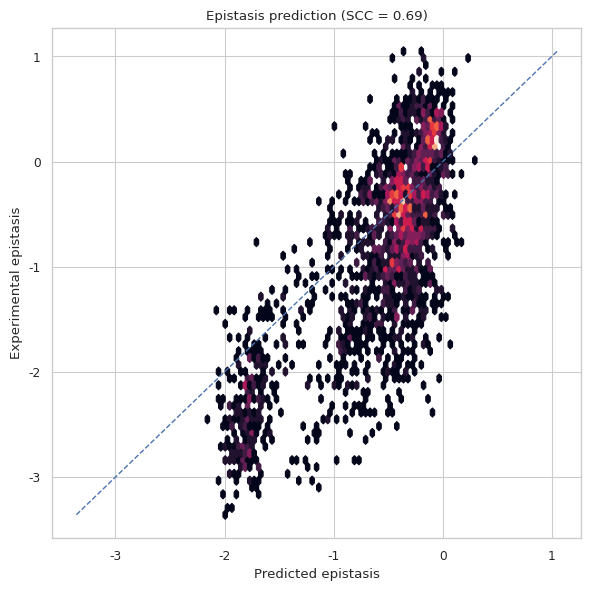

In [9]:
# Spearman 相关
scc_epi, _ = spearmanr(df["epi_ddg_pre"], df["epi_ddg"])

plt.figure(figsize=(6, 6))

plt.hexbin(
    df["epi_ddg_pre"],
    df["epi_ddg"],
    gridsize=60,
    mincnt=1
)

# y = x 参考线
lims = [
    min(df["epi_ddg_pre"].min(), df["epi_ddg"].min()),
    max(df["epi_ddg_pre"].max(), df["epi_ddg"].max())
]
plt.plot(lims, lims, linestyle="--", linewidth=1)

plt.xlabel("Predicted epistasis")
plt.ylabel("Experimental epistasis")
plt.title(f"Epistasis prediction (SCC = {scc_epi:.2f})")

plt.tight_layout()
plt.show()

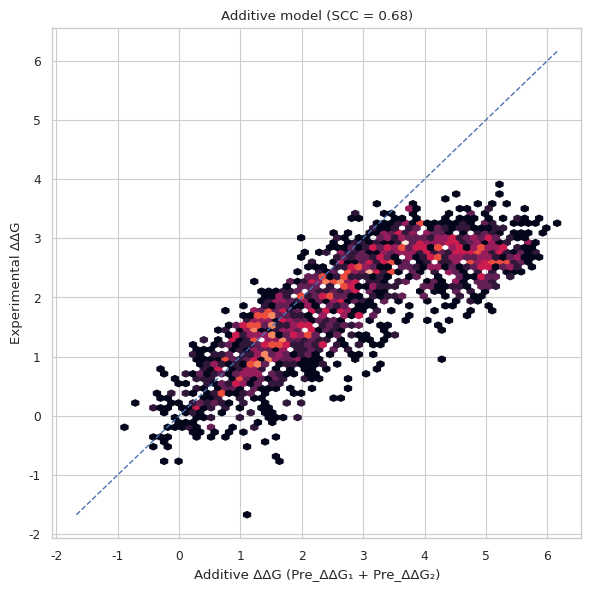

In [10]:
scc_add, _ = spearmanr(df["ddg_add_pre"], df["ddg_x"])

plt.figure(figsize=(6, 6))

plt.hexbin(
    df["ddg_add"],
    df["ddg_x"],
    gridsize=60,
    mincnt=1
)

lims = [
    min(df["ddg_add"].min(), df["ddg_x"].min()),
    max(df["ddg_add"].max(), df["ddg_x"].max())
]
plt.plot(lims, lims, linestyle="--", linewidth=1)

plt.xlabel("Additive ΔΔG (Pre_ΔΔG₁ + Pre_ΔΔG₂)")
plt.ylabel("Experimental ΔΔG")
plt.title(f"Additive model (SCC = {scc_add:.2f})")

plt.tight_layout()
plt.show()

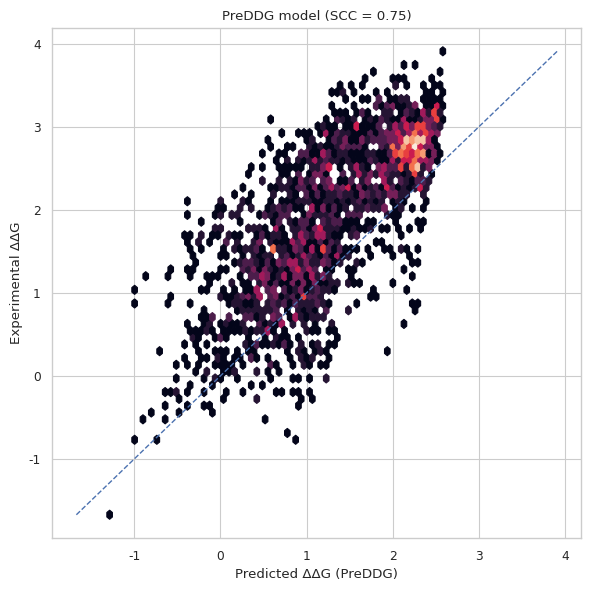

In [11]:
scc_preddg, _ = spearmanr(df["PreDDG"], df["ddg_x"])

plt.figure(figsize=(6, 6))

plt.hexbin(
    df["PreDDG"],
    df["ddg_x"],
    gridsize=60,
    mincnt=1
)

lims = [
    min(df["PreDDG"].min(), df["ddg_x"].min()),
    max(df["PreDDG"].max(), df["ddg_x"].max())
]
plt.plot(lims, lims, linestyle="--", linewidth=1)

plt.xlabel("Predicted ΔΔG (PreDDG)")
plt.ylabel("Experimental ΔΔG")
plt.title(f"PreDDG model (SCC = {scc_preddg:.2f})")

plt.tight_layout()
plt.show()